# Play Colour Bomb Gridworlds

Choose an environment with the buttons, preview an `rgb_array` frame inline, then run the last cell to play with the arrow keys or WASD in a pygame window.

In [1]:
import ipywidgets as widgets
from IPython.display import display
from PIL import Image

VALID_ENV_NAMES = (
    "colour_bomb_grid_world",
    "colour_bomb_grid_world_v2",
    "colour_bomb_grid_world_v3",
)

def make_env(env_name, **kwargs):
    if env_name == "colour_bomb_grid_world":
        from masa.envs.tabular.colour_bomb_grid_world import ColourBombGridWorld

        return ColourBombGridWorld(**kwargs)
    if env_name == "colour_bomb_grid_world_v2":
        from masa.envs.tabular.colour_bomb_grid_world_v2 import ColourBombGridWorldV2

        return ColourBombGridWorldV2(**kwargs)
    if env_name == "colour_bomb_grid_world_v3":
        from masa.envs.tabular.colour_bomb_grid_world_v3 import ColourBombGridWorldV3

        return ColourBombGridWorldV3(**kwargs)
    raise ValueError(f"env_name must be one of {VALID_ENV_NAMES!r}")

ENV_SELECTOR = widgets.ToggleButtons(
    options=VALID_ENV_NAMES,
    value="colour_bomb_grid_world",
    description="Env",
)
display(ENV_SELECTOR)

ENV_NAME = ENV_SELECTOR.value
SEED = 0


ToggleButtons(description='Env', options=('colour_bomb_grid_world', 'colour_bomb_grid_world_v2', 'colour_bomb_…

reset: {'obs': 74, 'info': {}}


/home/omar/Projects/amethyst/MASA-Safe-RL/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


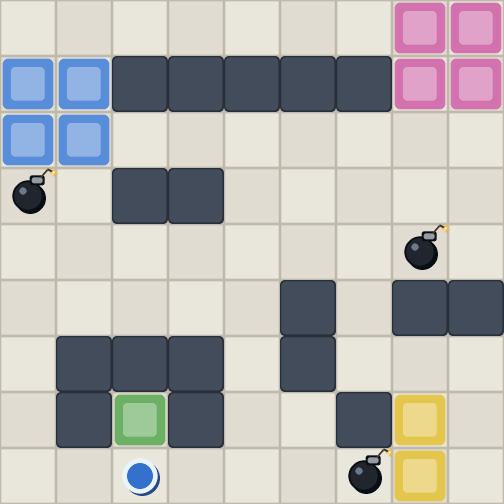

In [2]:
ENV_NAME = ENV_SELECTOR.value
preview_env = make_env(ENV_NAME, render_mode="rgb_array", render_window_size=512)
obs, info = preview_env.reset(seed=SEED)
print("reset:", {"obs": obs, "info": info})
display(Image.fromarray(preview_env.render()))
preview_env.close()


In [3]:
def play_env(env_name=None, seed=SEED):
    import pygame

    if env_name is None:
        env_name = ENV_SELECTOR.value
    action_keys = {
        pygame.K_LEFT: 0,
        pygame.K_a: 0,
        pygame.K_RIGHT: 1,
        pygame.K_d: 1,
        pygame.K_DOWN: 2,
        pygame.K_s: 2,
        pygame.K_UP: 3,
        pygame.K_w: 3,
        pygame.K_SPACE: 4,
    }
    env = make_env(env_name, render_mode="human", render_window_size=512)
    obs, info = env.reset(seed=seed)
    finished = False
    print("Controls: arrows or WASD move, Space waits, R resets, Q or Escape quits.")
    print("reset:", {"obs": obs, "info": info})

    try:
        running = True
        while running and not env.human_window_closed:
            action = None
            for event in pygame.event.get():
                if not env.handle_pygame_event(event):
                    running = False
                    break
                if event.type != pygame.KEYDOWN:
                    continue
                if event.key in (pygame.K_q, pygame.K_ESCAPE):
                    running = False
                    break
                if event.key == pygame.K_r:
                    obs, info = env.reset(seed=seed)
                    finished = False
                    print("reset:", {"obs": obs, "info": info})
                    continue
                if event.key in action_keys and not finished:
                    action = action_keys[event.key]

            if action is None:
                env.render()
                continue

            obs, reward, terminated, truncated, info = env.step(action)
            finished = terminated or truncated
            print({
                "obs": obs,
                "reward": reward,
                "terminated": terminated,
                "truncated": truncated,
                "info": info,
            })
    finally:
        env.close()

play_env(seed=SEED)


Controls: arrows or WASD move, Space waits, R resets, Q or Escape quits.
reset: {'obs': 74, 'info': {}}
